In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
import os
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error

In [2]:
df=pd.read_csv('house')
X=df.drop(columns="price")
y=df['price']
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state = 42)

In [3]:
result=[]
for filename in os.listdir():
    if filename.endswith('.joblib'):
        try:
            model=joblib.load(filename)
            y_pred=model.predict(X_test)
            mse=mean_squared_error(y_test, y_pred)
            r2=r2_score(y_test, y_pred)
            mape=mean_absolute_percentage_error(y_test, y_pred)*100
            mae=mean_absolute_error(y_test, y_pred)
            result.append({
                'Model_Name':filename,
                'MSE':round(mse,4),
                'MAE':round(mae,4),
                'R2 Score':round(r2,4),
                'MAPE':f'{mape:.2f}%'
                    })
        except Exception as e:
            print(f"Ошибка при чтении модели {filename}")
if len(result)>0:
    result_df=pd.DataFrame(result)
    display(result_df)
else:
    print("Файлов не найденно")
                

,Model_Name,MSE,MAE,R2 Score,MAPE
0,catboost_model.joblib,3.131539e+11,4.667155e+05,0.8984,8.55%
1,DecisionTree_model.joblib,6.303732e+11,6.482577e+05,0.7955,11.68%
2,lasso_model.joblib,2.373096e+11,3.781861e+05,0.9230,7.29%
3,linear_regression_model.joblib,2.373094e+11,3.781861e+05,0.9230,7.29%
4,SVR_model.joblib,3.566763e+12,1.606484e+06,-0.1571,30.52%


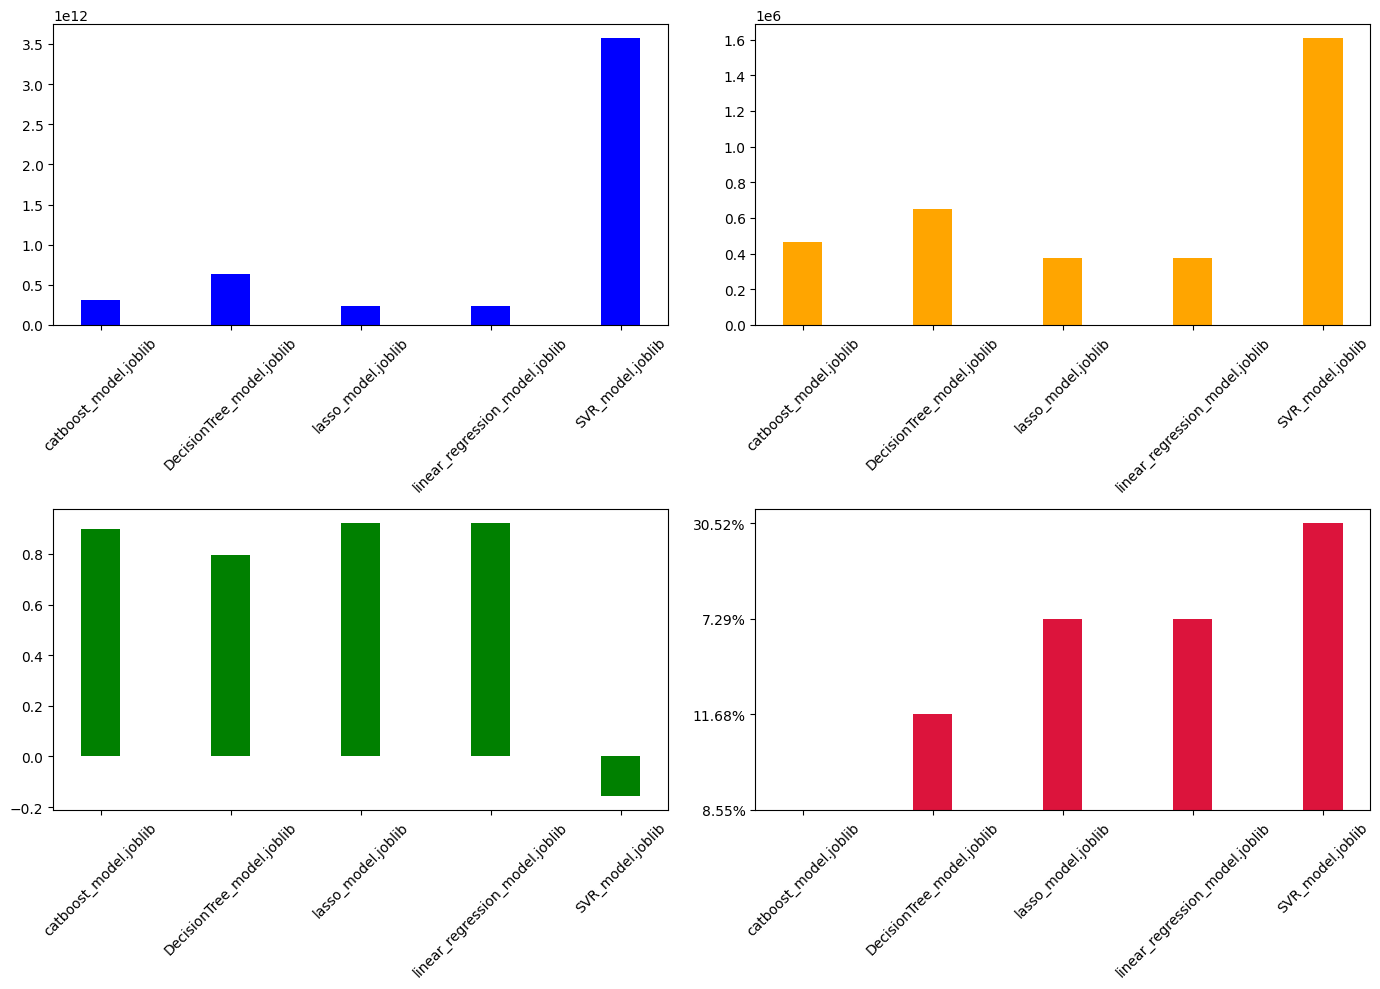

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
result_df.index=result_df['Model_Name']
bar_width=0.3
index=range(len(result_df))
colors=['blue', 'orange', 'green', 'crimson']
fig, axs=plt.subplots(nrows=2, ncols=2, figsize=(14,10))
axs=axs.flatten()
metrics=['MSE', 'MAE', 'R2 Score', 'MAPE']
for i, metric in enumerate(metrics):
    axs[i].bar(index, result_df[metric], width=bar_width, color=colors[i])
    axs[i].set_xticks(index)
    axs[i].set_xticklabels(result_df['Model_Name'], rotation=45)
plt.tight_layout()  # <-- рекомендуется, чтобы избежать наложения подписей
plt.show()

In [5]:
models={}
for filename in os.listdir():
    if filename.endswith('.joblib'):
        try:
            model=joblib.load(filename)
            models[filename[:-7]]=model
        except Exeption as e:
            print(f'ошибки при загрузке модели{filename}')
new_area=float(input("Площадь квартиры"))
new_rooms=int(input("Количество комнат"))
new_data=pd.DataFrame([[new_area, new_rooms]], columns=X.columns)
predictions={}
for model_name, model in models.items():
    prediction=model.predict(new_data)[0]
    predictions[model_name]=prediction

for model_name, pred_value in predictions.items():
    print(f"Модель {model_name} = {pred_value:.2f} рублей")

Площадь квартиры 100
Количество комнат 4


Модель catboost_model = 4568725.21 рублей
Модель DecisionTree_model = 4239851.00 рублей
Модель lasso_model = 4558789.43 рублей
Модель linear_regression_model = 4558790.63 рублей
Модель SVR_model = 5027032.39 рублей


In [6]:
from scipy.spatial.distance import cdist
new_data=pd.DataFrame([[80,3]],columns=X.columns)
distances=cdist(new_data,X,metric='euclidean')[0]
df_dist=df.copy()
df_dist['distance']=distances

near_houses=df_dist.nsmallest(5, 'distance')
display(near_houses)

,square_meters,rooms,price,distance
94,82,3,3425313.0,2.000000
86,82,2,3883488.0,2.236068
90,77,2,3548199.0,3.162278
49,84,2,3236693.0,4.123106
97,86,4,3905991.0,6.082763


In [7]:
from sklearn.preprocessing import StandardScaler

# 1. Загрузка и подготовка данных
df = pd.read_csv('house')          # Читаем файл с данными о домах
X = df.drop(columns="price")       # X - это признаки (площадь, комнаты и т.д.), удаляем цену, так как ее мы обычно хотим предсказать
y = df['price']                    # y - это целевая переменная (цена), сохраняем отдельно

scaler=StandardScaler()
scaled_X=scaler.fit_transform(X)

# Передавать новые данные как DataFrame с теми же именами столбцов
new_data_raw = pd.DataFrame([[80, 3]], columns=X.columns)  
new_data=scaler.transform(new_data_raw)

distances=cdist(new_data,scaled_X,metric='euclidean')[0]
df_dist=df.copy()
df_dist['distance']=distances


near_houses=df_dist.nsmallest(5, 'distance')
display(near_houses)

,square_meters,rooms,price,distance
94,82,3,3425313.0,0.047713
18,87,3,3861354.0,0.166996
66,89,3,3530053.0,0.214709
89,90,3,3077885.0,0.238566
36,67,3,3754470.0,0.310136
